In [1]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import scipy.integrate as integrate
import scipy.ndimage as ndimage

import matplotlib.pyplot as plt
import matplotlib.colors as clr
import seaborn as sn


### Preprocessing

In [2]:
# Load data
data = pd.read_csv('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/data/Subject001_left_global_acc.csv')

In [3]:
# Get time
time = data['# time'].to_numpy()
fs = int(1 / np.diff(time).mean()) # sampling frequency
dt = 1 / fs # sampling period

# Get acceleration and band-pass filter
acceleration = data[[f'acc_{ax}' for ax in 'xyz']].to_numpy()
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=fs)
acceleration = signal.filtfilt(b, a, acceleration, axis=0)

# Get velocity and band-pass filter
velocity = integrate.cumulative_trapezoid(acceleration, dx=dt, axis=0, initial=0)
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=1/dt)
velocity = signal.filtfilt(b, a, velocity, axis=0)

# Get position and band-pass filter
position = integrate.cumulative_trapezoid(velocity, dx=dt, axis=0, initial=0)
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=1/dt)
position = signal.filtfilt(b, a, position, axis=0)

# Get power and band-pass filter
power = acceleration * velocity
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=fs)
power = signal.filtfilt(b, a, power, axis=0)

# Get total power along XYZ
power_total = power.sum(1)

In [4]:
# Trim data to focus on 100-150 seconds
mask_time = (time >= 200) * (time < 500)
time = time[mask_time]
acceleration = acceleration[mask_time]
velocity = velocity[mask_time]
position = position[mask_time]
power = power[mask_time]
power_total = power_total[mask_time]

Text(0.5, 0, 'Time [s]')

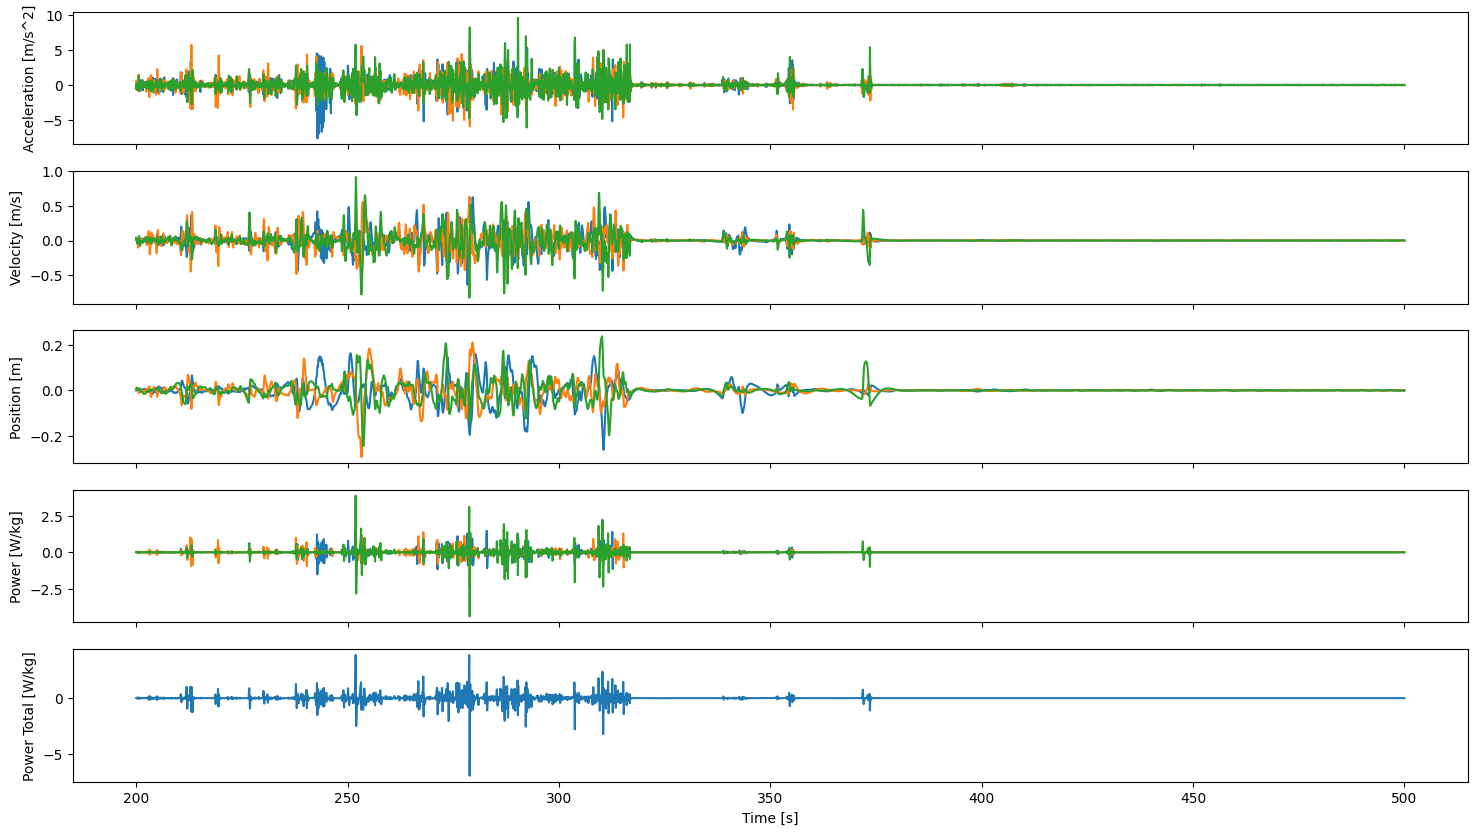

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(18, 10), sharex=True)

ax[0].plot(time, acceleration)
ax[1].plot(time, velocity)
ax[2].plot(time, position)
ax[3].plot(time, power)
ax[4].plot(time, power_total)

ax[0].set_ylabel('Acceleration [m/s^2]')
ax[1].set_ylabel('Velocity [m/s]')
ax[2].set_ylabel('Position [m]')
ax[3].set_ylabel('Power [W/kg]')
ax[4].set_ylabel('Power Total [W/kg]')
ax[4].set_xlabel('Time [s]')

### Wavelet transform

In [6]:
# Define acceleration wavelet
def accelerationWavelet(M: int, s: float):
    '''Wavelet corresponding to acceleration in a primitive movement

    :param M: length (in samples) of the wavelet
    :param s: width (in samples) of the wavelet
    '''
    x = (np.arange(M) - (M - 1) / 2) / s
    wavelet = (x > -0.5) * (x < 0.5) * 29 / 4 * x * (4 * x ** 2 - 1)
    output = np.sqrt(1 / s) * wavelet
    return output

# Define power wavelet
def powerWavelet(M: int, s: float):
    '''Wavelet corresponding to power (dE/dt) in a primitive movement

    :param M: length (in samples) of the wavelet
    :param s: width (in samples) of the wavelet
    '''
    x = (np.arange(M) - (M - 1) / 2) / s
    wavelet = (x > -0.5) * (x < 0.5) * 40 / 3 * x * (4 * x ** 2 - 1) ** 3
    output = np.sqrt(1 / s) * wavelet
    return output

In [7]:
# Define widths range to compute wavelet transform
wmin, wmax = 0.02, 5 # in seconds

# Define widths to compute wavelet transform
widths = np.logspace(np.log10(wmin), np.log10(wmax), 101, base=10) # in seconds
widths_samples = widths / dt # in samples

# Get resolution of widths
dw = np.diff(np.log10(widths)).mean() # in decades

In [8]:
# Compute wavelet transform for acceleration in each axis, and then aggregate them with norm
wavelet_accel = np.stack([signal.cwt(ai, accelerationWavelet, widths_samples) for ai in acceleration.T], axis=2)
wavelet_accel = np.linalg.norm(wavelet_accel, axis=2)

# Compute wavelet transform for power
wavelet_power = signal.cwt(power_total, powerWavelet, widths_samples)

/tmp/ipykernel_1653636/750981725.py:2: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet_accel = np.stack([signal.cwt(ai, accelerationWavelet, widths_samples) for ai in acceleration.T], axis=2)
/tmp/ipykernel_1653636/750981725.py:6: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet_power = signal.cwt(power_total, powerWavelet, widths_samples)


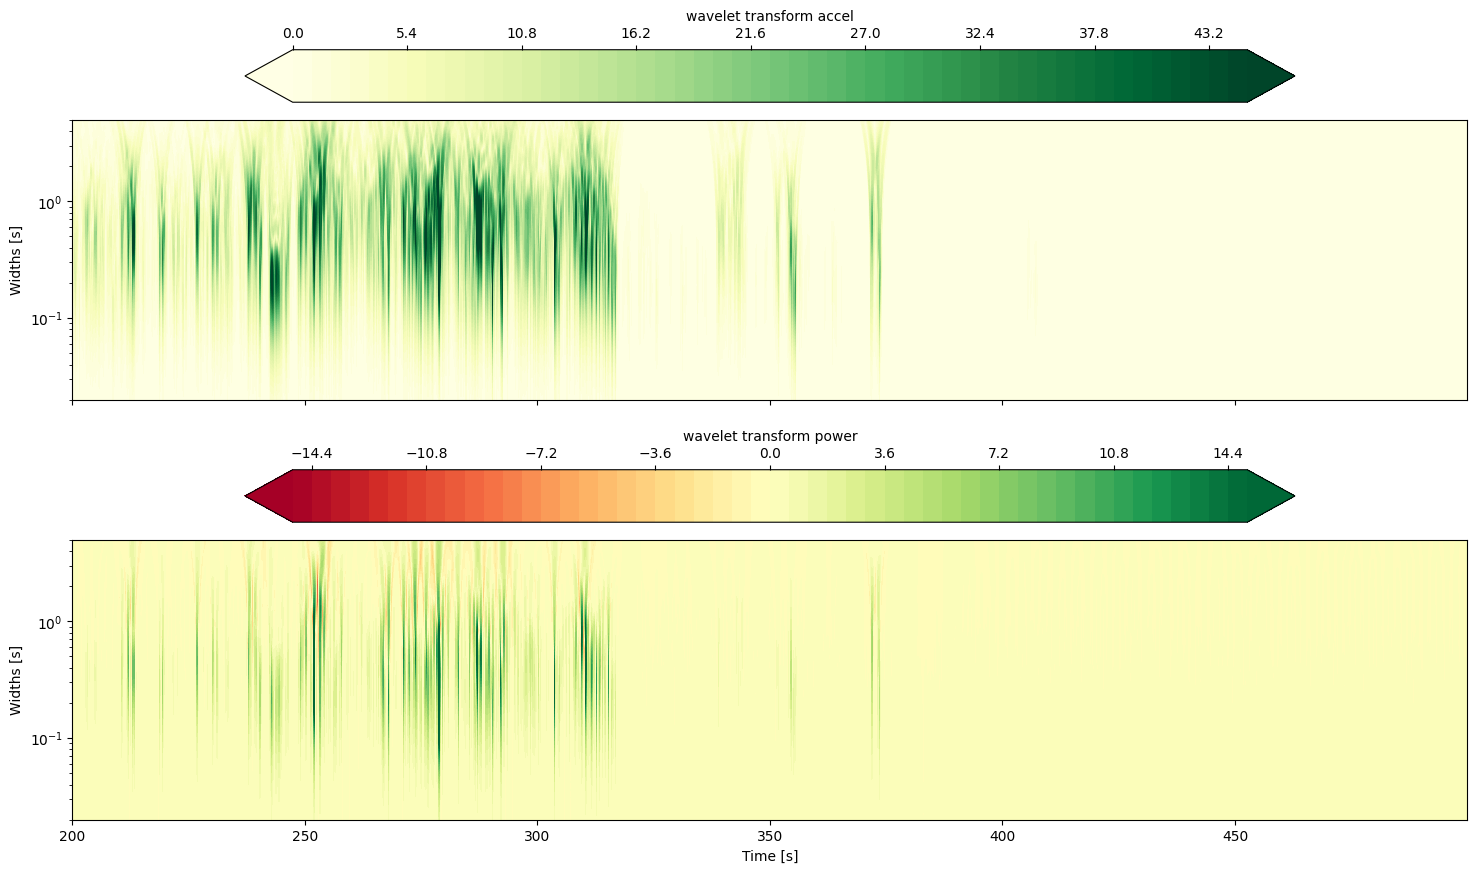

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(18, 10), sharex=True, sharey=True)

v_accel = 45 # max(np.abs(np.quantile(wavelet_accel, (0.005, 0.995))))
v_power = 15 # max(np.abs(np.quantile(wavelet_power, (0.005, 0.995))))

qd_accel = ax[0].contourf(time, widths, wavelet_accel, vmin=0, vmax=v_accel,
                          levels=np.linspace(0, v_accel, 51), cmap='YlGn', extend='both')
qd_power = ax[1].contourf(time, widths, wavelet_power, vmin=-v_power, vmax=v_power,
                          levels=np.linspace(-v_power, v_power, 51), cmap='RdYlGn', extend='both')

cbar_accel = plt.colorbar(qd_accel, ax=ax[0], location='top', label='wavelet transform accel')
cbar_power = plt.colorbar(qd_power, ax=ax[1], location='top', label='wavelet transform power')

ax[0].set_ylabel('Widths [s]')
ax[1].set_ylabel('Widths [s]')
ax[1].set_xlabel('Time [s]')
ax[0].set_yscale('log')

### P2P detection

In [10]:
# Define window hyperparameters to obtain local maxima
win_height = int(0.5 / dw) # numerator in decades
win_width = int(0.3 / dt) # numerator in seconds

# Define threshold hyperparameters to obtain local maxima
threshold_accel = 1
threshold_power = 1/4

# Define range of widths hyperparameters to obtain local maxima
width_min = 0.1
width_max = 2

In [11]:
# Extract local maxima from acceleration
maxima_accel = np.nonzero((ndimage.maximum_filter(wavelet_accel, size=(win_height, win_width)) == wavelet_accel) *
                          (wavelet_accel > threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 

# Extract local maxima from power
maxima_power = np.nonzero((ndimage.maximum_filter(wavelet_power, size=(win_height, win_width)) == wavelet_power) *
                          (wavelet_power > threshold_power) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 

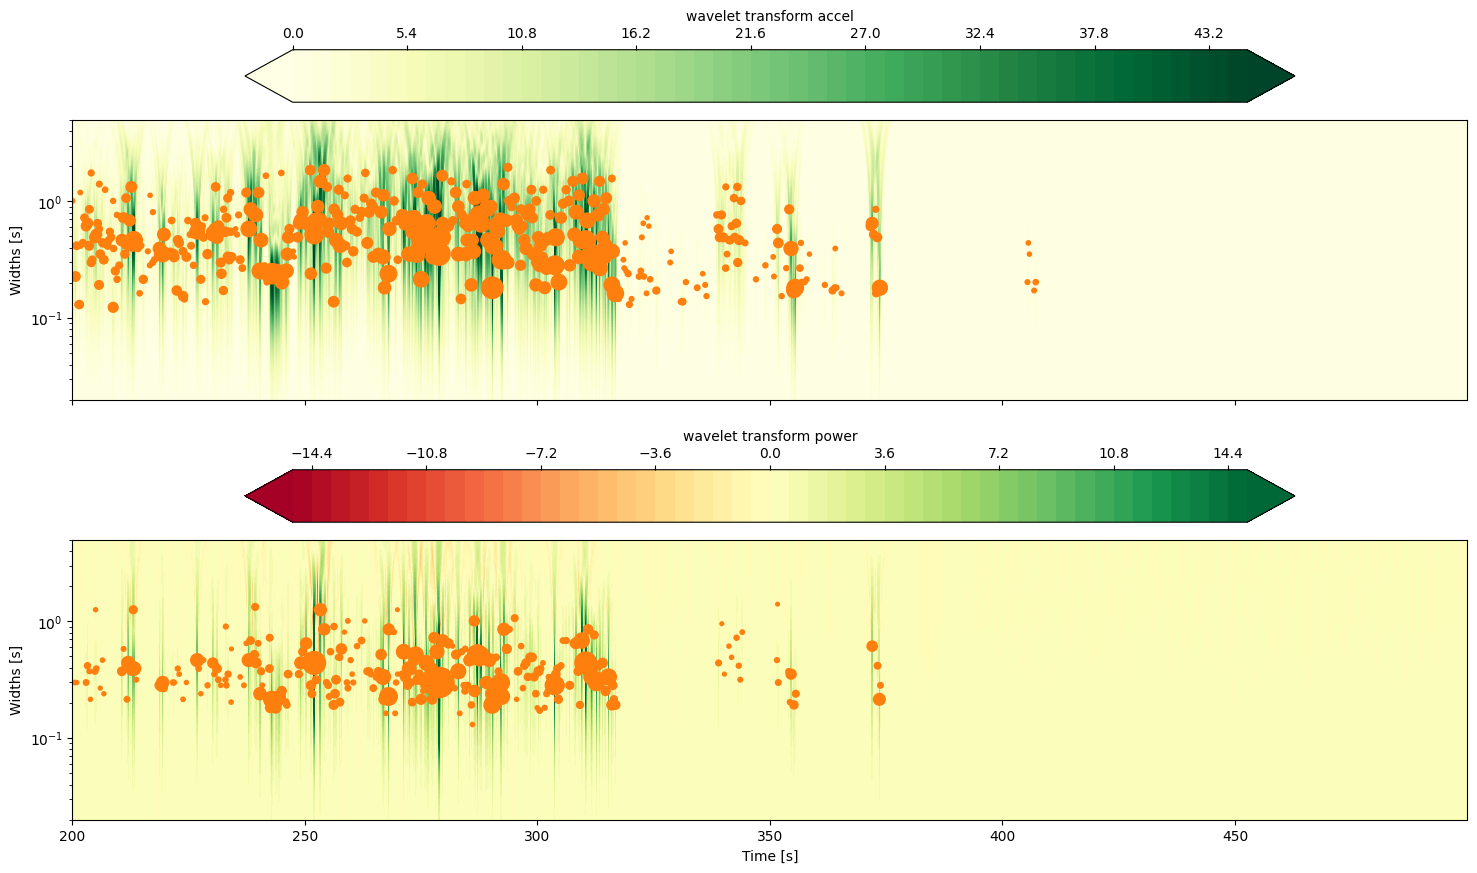

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(18, 10), sharex=True, sharey=True)

qd_accel = ax[0].contourf(time, widths, wavelet_accel, vmin=0, vmax=v_accel,
                          levels=np.linspace(0, v_accel, 51), cmap='YlGn', extend='both')
qd_power = ax[1].contourf(time, widths, wavelet_power, vmin=-v_power, vmax=v_power,
                          levels=np.linspace(-v_power, v_power, 51), cmap='RdYlGn', extend='both')

cbar_accel = plt.colorbar(qd_accel, ax=ax[0], location='top', label='wavelet transform accel')
cbar_power = plt.colorbar(qd_power, ax=ax[1], location='top', label='wavelet transform power')

ax[0].scatter(time[maxima_accel[1]], widths[maxima_accel[0]],
              s=5+2*(wavelet_accel[maxima_accel] / np.sqrt(widths[maxima_accel[0]])), color='C1')
ax[1].scatter(time[maxima_power[1]], widths[maxima_power[0]],
              s=5+6*(wavelet_power[maxima_power] / np.sqrt(widths[maxima_power[0]])), color='C1')

ax[0].set_ylabel('Widths [s]')
ax[1].set_ylabel('Widths [s]')
ax[1].set_xlabel('Time [s]')
ax[0].set_yscale('log')

In [13]:
# Tie break when two or more P2P overlap using acceleration
values_accel = wavelet_accel[maxima_accel]
order_accel = np.argsort(values_accel)[::-1]

mask_p2p_accel = np.zeros_like(time)
p2p_accel = []
for idx in order_accel:
    center, width = time[maxima_accel[1][idx]], widths[maxima_accel[0][idx]]
    ampl = values_accel[idx] / np.sqrt(width)
    tini, tfin = center - width / 2, center + width / 2
    new_mask = (time >= center - width / 2) * (time < center + width / 2)
    meanvel = np.linalg.norm(velocity[new_mask], axis=1).mean()
    displ = np.linalg.norm(position[new_mask][-1] - position[new_mask][0])
    if np.any(mask_p2p_accel + new_mask > 1):
        continue
    else:
        mask_p2p_accel += new_mask
        p2p_accel.append([center, width, ampl, tini, tfin, meanvel, displ])
mask_p2p_accel = mask_p2p_accel > 0
p2p_accel = np.array(p2p_accel).T

# Tie break when two or more P2P overlap using power
values_power = wavelet_power[maxima_power]
order_power = np.argsort(values_power)[::-1]

mask_p2p_power = np.zeros_like(time)
p2p_power = []
for idx in order_power:
    center, width = time[maxima_power[1][idx]], widths[maxima_power[0][idx]]
    ampl = values_power[idx] / np.sqrt(width)
    tini, tfin = center - width / 2, center + width / 2
    new_mask = (time >= center - width / 2) * (time < center + width / 2)
    meanvel = np.linalg.norm(velocity[new_mask], axis=1).mean()
    displ = np.linalg.norm(position[new_mask][-1] - position[new_mask][0])
    if np.any(mask_p2p_power + new_mask > 1):
        continue
    else:
        mask_p2p_power += new_mask
        p2p_power.append([center, width, ampl, tini, tfin, meanvel, displ])
mask_p2p_power = mask_p2p_power > 0
p2p_power = np.array(p2p_power).T

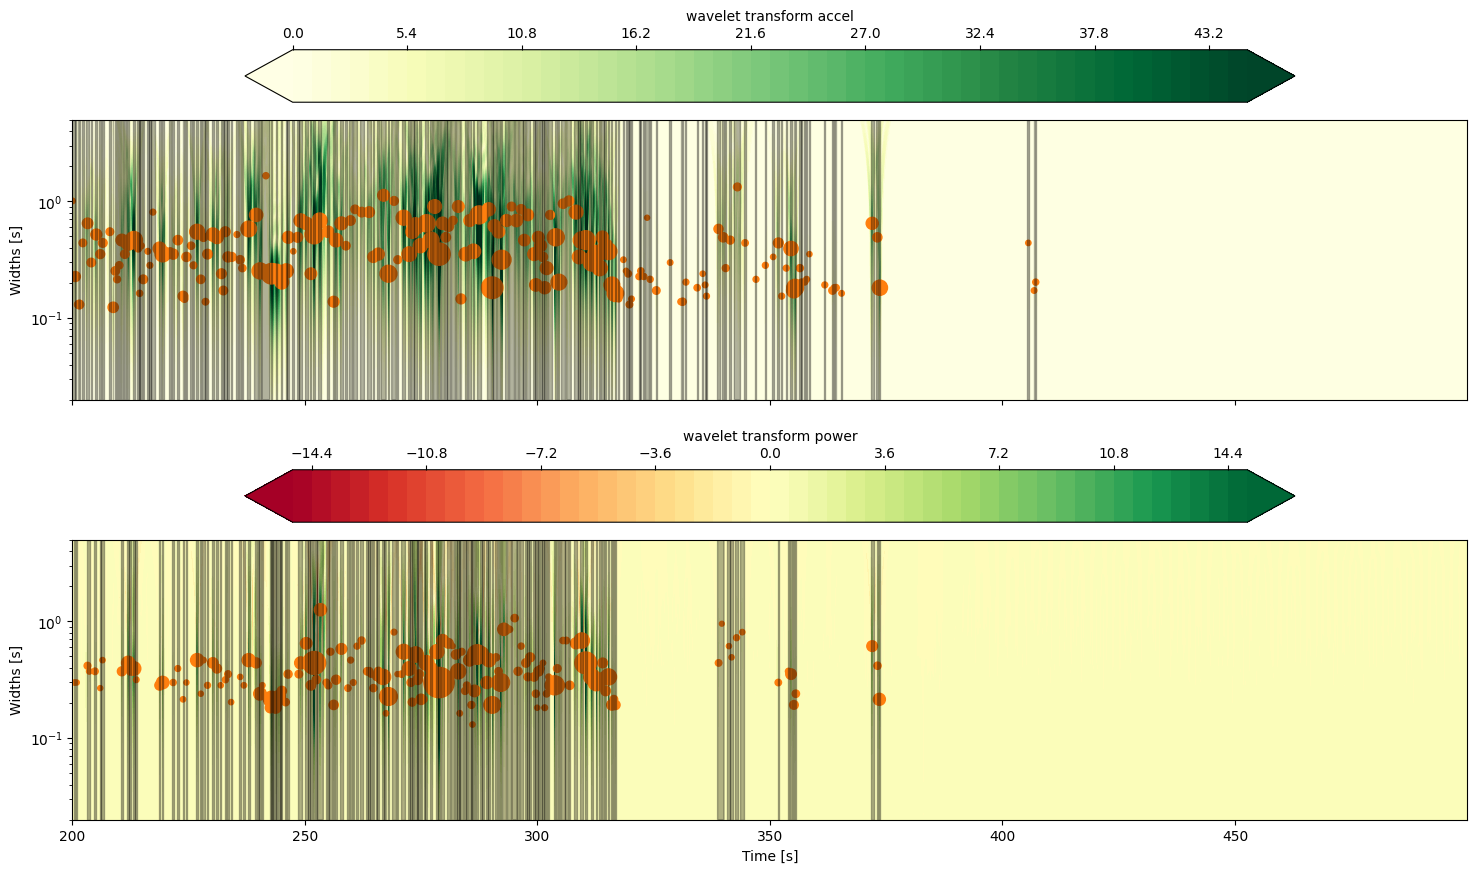

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(18, 10), sharex=True, sharey=True)

qd_accel = ax[0].contourf(time, widths, wavelet_accel, vmin=0, vmax=v_accel,
                          levels=np.linspace(0, v_accel, 51), cmap='YlGn', extend='both')
qd_power = ax[1].contourf(time, widths, wavelet_power, vmin=-v_power, vmax=v_power,
                          levels=np.linspace(-v_power, v_power, 51), cmap='RdYlGn', extend='both')

cbar_accel = plt.colorbar(qd_accel, ax=ax[0], location='top', label='wavelet transform accel')
cbar_power = plt.colorbar(qd_power, ax=ax[1], location='top', label='wavelet transform power')

ax[0].scatter(p2p_accel[0], p2p_accel[1], s=10+2*p2p_accel[2], color='C1')
ax[1].scatter(p2p_power[0], p2p_power[1], s=10+6*p2p_power[2], color='C1')

ax[0].fill_between(time, 0, 1, where=mask_p2p_accel, color='black', alpha=0.3, transform=ax[0].get_xaxis_transform())
ax[1].fill_between(time, 0, 1, where=mask_p2p_power, color='black', alpha=0.3, transform=ax[1].get_xaxis_transform())

ax[0].set_ylabel('Widths [s]')
ax[1].set_ylabel('Widths [s]')
ax[1].set_xlabel('Time [s]')
ax[0].set_yscale('log')

Text(0.5, 0, 'Time [s]')

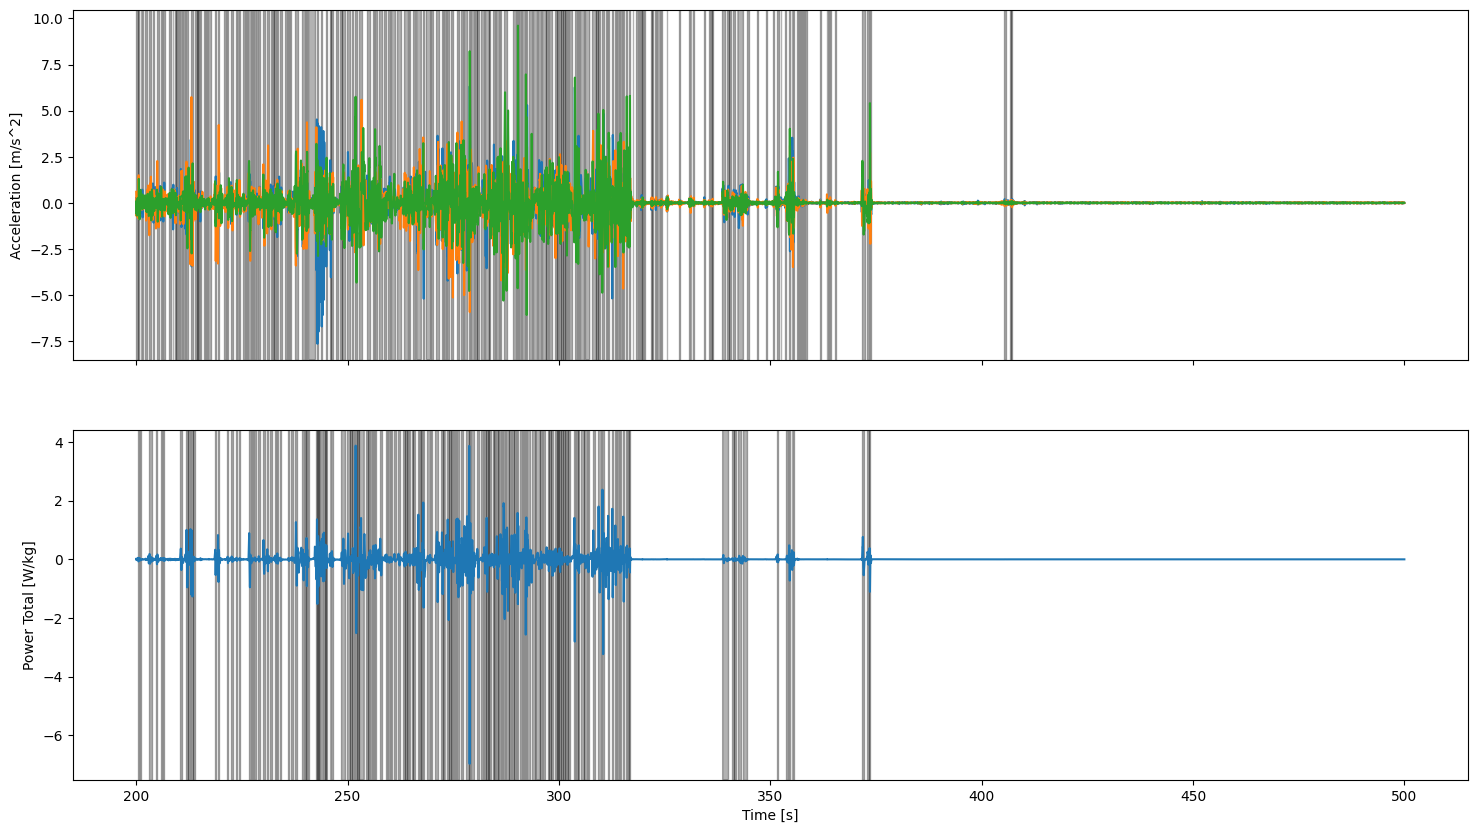

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ax[0].plot(time, acceleration)
ax[1].plot(time, power_total)

ax[0].fill_between(time, 0, 1, where=mask_p2p_accel, color='black', alpha=0.3, transform=ax[0].get_xaxis_transform())
ax[1].fill_between(time, 0, 1, where=mask_p2p_power, color='black', alpha=0.3, transform=ax[1].get_xaxis_transform())

ax[0].set_ylabel('Acceleration [m/s^2]')
ax[1].set_ylabel('Power Total [W/kg]')
ax[1].set_xlabel('Time [s]')

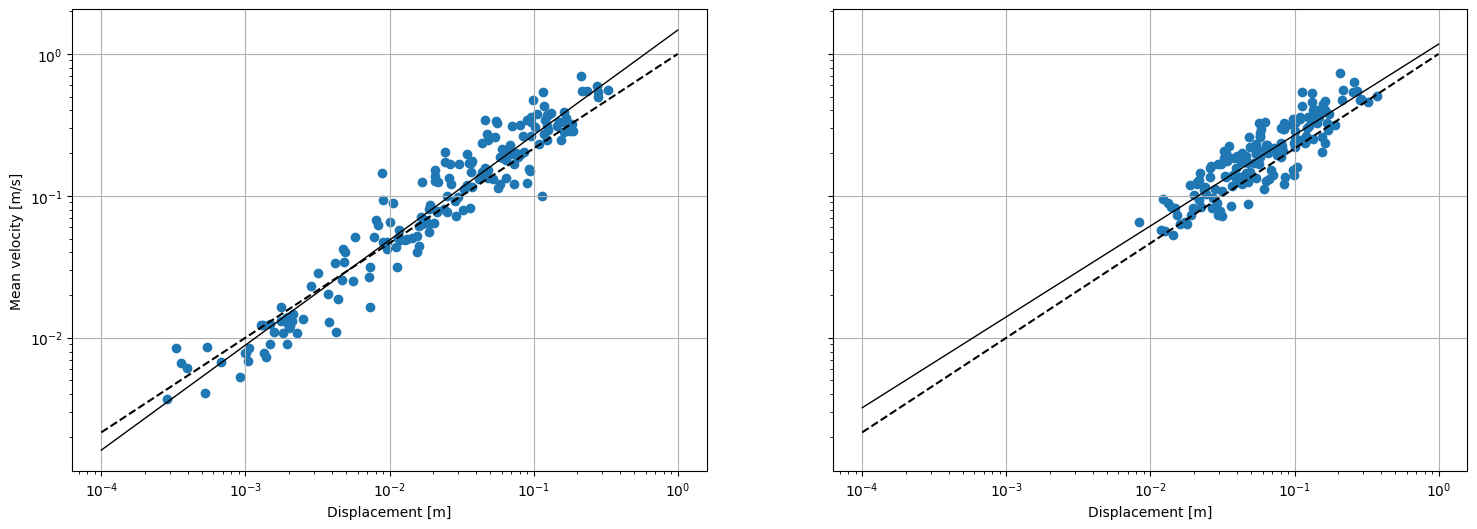

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

x_accel = p2p_accel[6]
y_accel = p2p_accel[5]
x_power = p2p_power[6]
y_power = p2p_power[5]

ax[0].scatter(x_accel, y_accel)
ax[1].scatter(x_power, y_power)

ax[0].plot([1e-4, 1], [1e-4 ** (2/3), 1 ** (2/3)], '--', color='k')
ax[1].plot([1e-4, 1], [1e-4 ** (2/3), 1 ** (2/3)], '--', color='k')

log_data = np.log10(np.stack([10*np.ones_like(x_accel), x_accel, y_accel], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[0].plot([1e-4, 1], 10**coeffs[0]*np.array([1e-4, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)
log_data = np.log10(np.stack([10*np.ones_like(x_power), x_power, y_power], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[1].plot([1e-4, 1], 10**coeffs[0]*np.array([1e-4, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)

ax[0].set_ylabel('Mean velocity [m/s]')
ax[0].set_xlabel('Displacement [m]')
ax[1].set_xlabel('Displacement [m]')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].grid()
ax[1].grid()

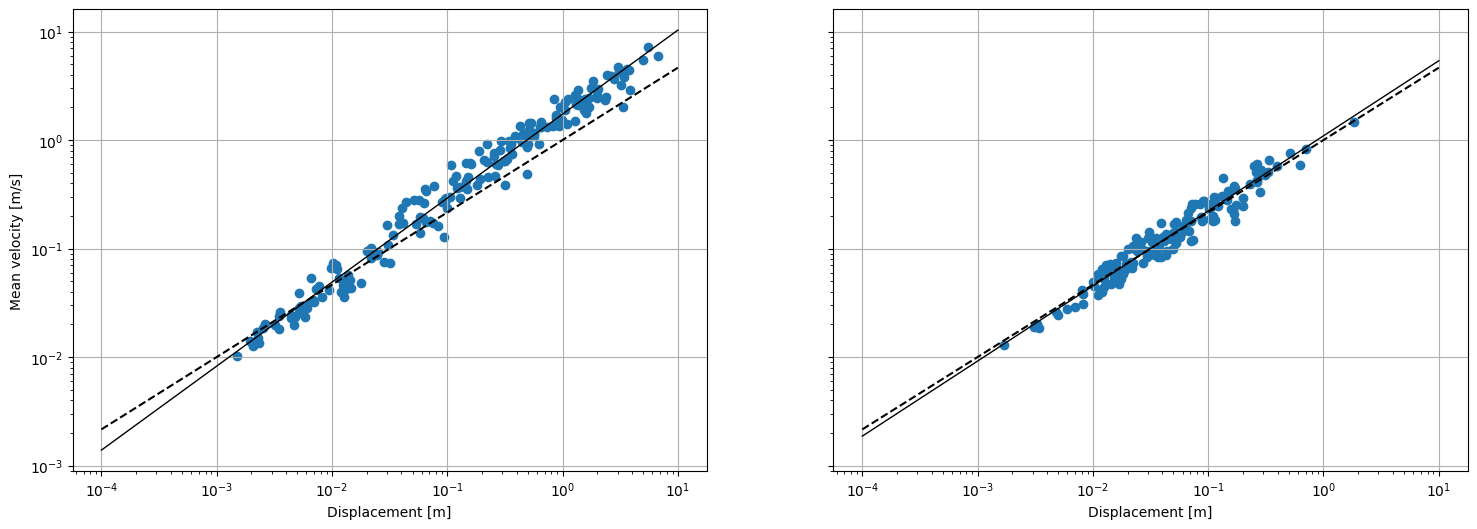

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

x_accel = 29 * np.sqrt(70) / 1575 * p2p_accel[2] * p2p_accel[1] ** 3
y_accel = 29 * np.sqrt(70) / 1575 * p2p_accel[2] * p2p_accel[1] ** 2
x_power = 64 * np.sqrt(21) / 945 * np.sqrt(p2p_power[2] * p2p_power[1]) * p2p_power[1] ** 2
y_power = 64 * np.sqrt(21) / 945 * np.sqrt(p2p_power[2] * p2p_power[1]) * p2p_power[1]

ax[0].scatter(x_accel, y_accel)
ax[1].scatter(x_power, y_power)

ax[0].plot([1e-4, 10], [1e-4 ** (2/3), 10 ** (2/3)], '--', color='k')
ax[1].plot([1e-4, 10], [1e-4 ** (2/3), 10 ** (2/3)], '--', color='k')

log_data = np.log10(np.stack([10*np.ones_like(x_accel), x_accel, y_accel], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[0].plot([1e-4, 10], 10**coeffs[0]*np.array([1e-4, 10])**coeffs[1], color='k', label='Loglog regression', lw=1)
log_data = np.log10(np.stack([10*np.ones_like(x_power), x_power, y_power], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[1].plot([1e-4, 10], 10**coeffs[0]*np.array([1e-4, 10])**coeffs[1], color='k', label='Loglog regression', lw=1)

ax[0].set_ylabel('Mean velocity [m/s]')
ax[0].set_xlabel('Displacement [m]')
ax[1].set_xlabel('Displacement [m]')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].grid()
ax[1].grid()

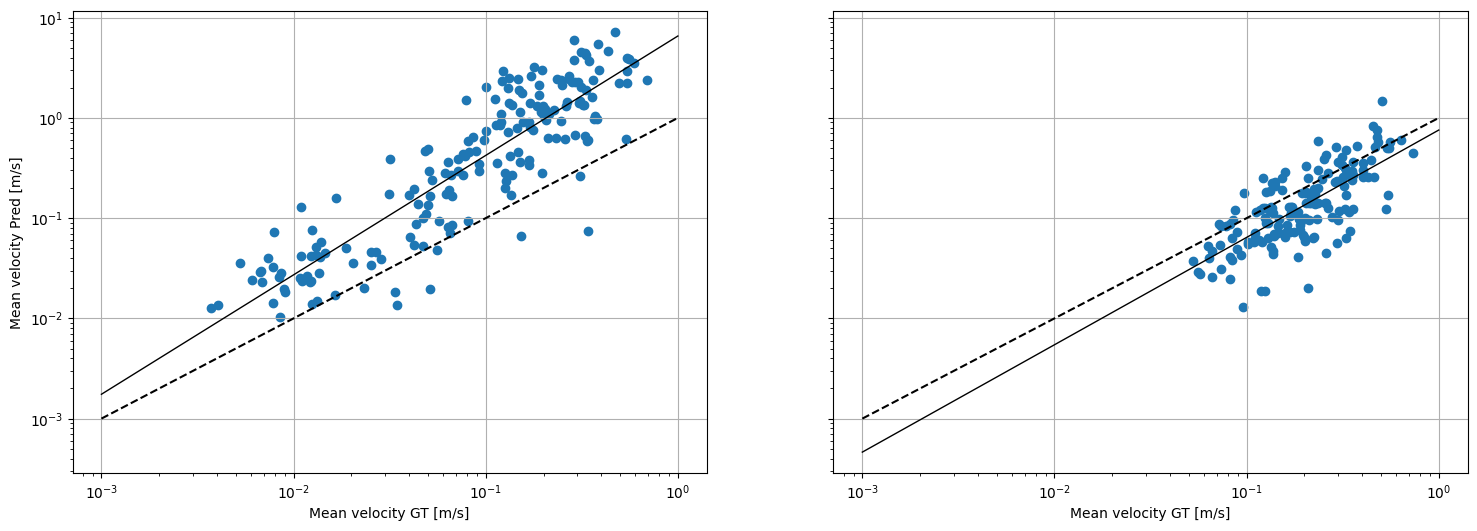

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

x_accel = p2p_accel[5]
y_accel = 29 * np.sqrt(70) / 1575 * p2p_accel[2] * p2p_accel[1] ** 2
x_power = p2p_power[5]
y_power = 64 * np.sqrt(21) / 945 * np.sqrt(p2p_power[2] * p2p_power[1]) * p2p_power[1]

ax[0].scatter(x_accel, y_accel)
ax[1].scatter(x_power, y_power)

ax[0].plot([1e-3, 1], [1e-3, 1], '--', color='k')
ax[1].plot([1e-3, 1], [1e-3, 1], '--', color='k')

log_data = np.log10(np.stack([10*np.ones_like(x_accel), x_accel, y_accel], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[0].plot([1e-3, 1], 10**coeffs[0]*np.array([1e-3, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)
log_data = np.log10(np.stack([10*np.ones_like(x_power), x_power, y_power], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[1].plot([1e-3, 1], 10**coeffs[0]*np.array([1e-3, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)

ax[0].set_xlabel('Mean velocity GT [m/s]')
ax[1].set_xlabel('Mean velocity GT [m/s]')
ax[0].set_ylabel('Mean velocity Pred [m/s]')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].grid()
ax[1].grid()

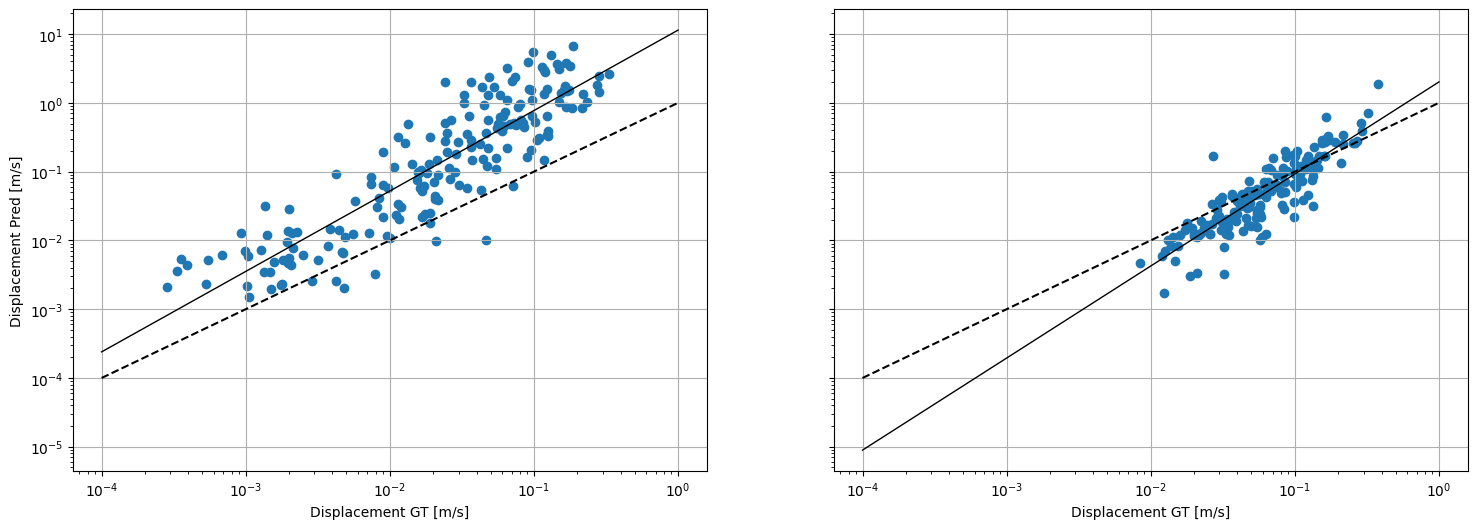

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

x_accel = p2p_accel[6]
y_accel = 29 * np.sqrt(70) / 1575 * p2p_accel[2] * p2p_accel[1] ** 3
x_power = p2p_power[6]
y_power = 64 * np.sqrt(21) / 945 * np.sqrt(p2p_power[2] * p2p_power[1]) * p2p_power[1] ** 2

ax[0].scatter(x_accel, y_accel)
ax[1].scatter(x_power, y_power)

ax[0].plot([1e-4, 1], [1e-4, 1], '--', color='k')
ax[1].plot([1e-4, 1], [1e-4, 1], '--', color='k')

log_data = np.log10(np.stack([10*np.ones_like(x_accel), x_accel, y_accel], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[0].plot([1e-4, 1], 10**coeffs[0]*np.array([1e-4, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)
log_data = np.log10(np.stack([10*np.ones_like(x_power), x_power, y_power], 1))
coeffs, _, _, _ = np.linalg.lstsq(log_data[:,0:2], log_data[:,2], rcond=None)
ax[1].plot([1e-4, 1], 10**coeffs[0]*np.array([1e-4, 1])**coeffs[1], color='k', label='Loglog regression', lw=1)

ax[0].set_xlabel('Displacement GT [m/s]')
ax[1].set_xlabel('Displacement GT [m/s]')
ax[0].set_ylabel('Displacement Pred [m/s]')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].grid()
ax[1].grid()